Exercise1: Consider the following linear model describing the relationship between $Y$ and variables $X_1$, $X_2$:  

$Y = 2X_1 - 3X_2 + 4$

Using this model, answer the following questions:  

- If $X_1 = 10$ and $X_2 = 40$, what is the value of $Y$?  
- If $X_1$ increases by 1 while $X_2$ remains constant, by how much does $Y$ change?  

In [1]:
def fun(x1, x2):
    return 2*x1 -3*x2 +4

print(fun(10, 40))

#2. Y = 2(x1 +1) -3x2 +4
# increases by 2

-96


<h4> Exercise2: Implement the Gradient Descent method for finding local minima and maxima of the function  
 
$y = \sin(x^2 + 6x + 7) + x^2 - x^3$  

Start with initial points $x_0 = 2$ and $x_0 = -1$, and experiment with different values of $\alpha$.  

In [ ]:
import numpy as np

def fun(x):
    return np.sin(x**2 + 6*x + 7) +x**2 -x**3

def diff(x):
    return -3*x**2 + 2*x + (2*x + 6)*np.cos(x**2 + 6*x + 7)

def grad(w, alpha=0.01):
    print(f'w = {w}, alpha = {alpha}')
    for i in range(100):
        w -= alpha*diff(w)
        if i%25 == 0:
            print(w)
    
grad(2, 0.1) #średni
grad(2) #lepszy
grad(2, 0.001) #jeszcze lepszy
grad(2, 0.0001) #najlepszy

grad(-1, 0.1) #bardziej średni
grad(-1) #lepszy
grad(-1, 0.001) #najlpeszy lepszy
grad(-1, 0.0001) #średni

w = 2, alpha = 0.1
3.3328330203333976
nan
nan
nan
w = 2, alpha = 0.01
2.1332833020333397
2.180011823524885
2.180042465991886
2.1800425176355
w = 2, alpha = 0.001
2.013328330203334
2.1413536311543435
2.1642747149797494
2.17236285387758
w = 2, alpha = 0.0001
2.0013328330203333
2.0314377132810315
2.055667797555848
2.0749276492164226
w = -1, alpha = 0.1
-0.33354126538114304
-0.6686699408162692
0.037608214617899094
0.034042966503437744
w = -1, alpha = 0.01
-0.9333541265381143
-0.3675077179159128
-0.3673997418691412
-0.36739973404455306
w = -1, alpha = 0.001
-0.9933354126538114
-0.8117264378009047
-0.6262129375608084
-0.4941547906187263
w = -1, alpha = 0.0001
-0.9993335412653811
-0.98251126606793
-0.9653771991998009
-0.947930708562537


C:\Users\kajaw\AppData\Local\Temp\ipykernel_15180\1736097250.py:7: RuntimeWarning: overflow encountered in scalar power
  return -3*x**2 + 2*x + (2*x + 6)*np.cos(x**2 + 6*x + 7)
C:\Users\kajaw\AppData\Local\Temp\ipykernel_15180\1736097250.py:7: RuntimeWarning: invalid value encountered in cos
  return -3*x**2 + 2*x + (2*x + 6)*np.cos(x**2 + 6*x + 7)


Exercise3: Consider the BostonHousing dataset. Split the data into training and test sets using an 4:1 ratio. Build a linear model to predict $medv$ using $indus$ and $rm$ as predictors. Evaluate the model's performance using $MSE$ and $R^2$ on both the training and test sets. Finally, analyze and interpret the results.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import pandas as pd

df = pd.read_csv('BostonHousing.csv')
df.head()

y = df['medv']
x = df[['indus', 'rm']]

x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, train_size=0.8, random_state=42)

model = LinearRegression()
model.fit(x_train, y_train)

r_sq = model.score(x_test, y_test)
print(r_sq)  #ma sie zbiliżać do 0, jest w maiare

mse = mean_squared_error(y_test, model.predict(x_test))
print(mse) #ma sie zbiliżać do 0, jest średni

0.4738047952188049
38.58788504742589


<h4> Exercise4: Consider the BostonHousing dataset once again. Split the data into training and test sets using an 4:1 ratio. Build a nonlinear model to predict $medv$ using $indus$ and $rm$ as predictors, exploring different transformations. Evaluate the model's performance using $MSE$ on both the training and test sets. Finally, analyze and interpret the results.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np

df = pd.read_csv('BostonHousing.csv')
df.head()

y = df['medv']
df['expindus'] = np.exp(-df['indus'])
df['indus2'] = df['indus']**2
x = df[['indus', 'rm', 'indus2']]

x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, train_size=0.8, random_state=42)


model = LinearRegression()
model.fit(x_train, y_train)


r_sq = model.score(x_test, y_test)
print(r_sq) #ciut lepiej

mse = mean_squared_error(y_test, model.predict(x_test))
print(mse) #ciut gorzej

0.4699599712138053
38.86984053729814


<h4> Exercise5: Cosider the following data

#### Assume the dependence between $y$ and $x$ can be described by the formula $y = ae^{-bx}$. Find parameters $a$ and $b$ using:
    
- The gradient descent method

- A built-in linear model

In [7]:
#gradient
x = np.array([-2.0, -1.68, -1.37, -1.05, -0.74, -0.42, -0.11, 0.21, 0.53, 0.84, 1.16, 1.47, 1.79, 2.11, 2.42, 2.74, 3.05, 3.37, 3.68, 4.0])
y = np.array([9.58, 8.05, 6.71, 5.57, 4.65, 4.03, 3.36, 2.81, 2.3, 1.83, 1.65, 1.37, 1.15, 0.99, 0.86, 0.65, 0.54, 0.43, 0.4, 0.29])

def fun(x, a, b):
    return a* np.exp(-b*x)

def L(a,b):
    a =0
    for i in range(len(x)):
        a += (y[i]-fun(x[i],a,b))**2 
    return 1/len(x)*a

def pochodna_L(a,b):
    p_a = 0
    p_b = 0
    for i in range(len(x)):
        p_a += -2 * (-a*np.exp(-b*x[i]) +y[i])*np.exp(-b*x[i])
        p_b += 2*a*x[i] * (-a*np.exp(-b*x[i]) + y[i])* np.exp(-b*x[i])
    return p_a/len(x), p_b/len(x)

a, b = 1, 1
alfa = 0.01
for i in range(1000):
    a -= alfa*pochodna_L(a,b)[0]
    b -= alfa*pochodna_L(a,b)[1]
    if i%100 == 0:
        print(a, b)

1.065277602004504 1.0744002825366226
2.272065949061864 0.7400844428816548
2.7799333376140485 0.624941134101245
2.988496233321738 0.5846207505565633
3.068511617009717 0.5701492012602095
3.098266153823579 0.5649056943777196
3.1091963683479142 0.5629981305308276
3.1131932678842245 0.5623030735562158
3.1146523818827245 0.5620496669524028
3.115184721393209 0.5619572589008658


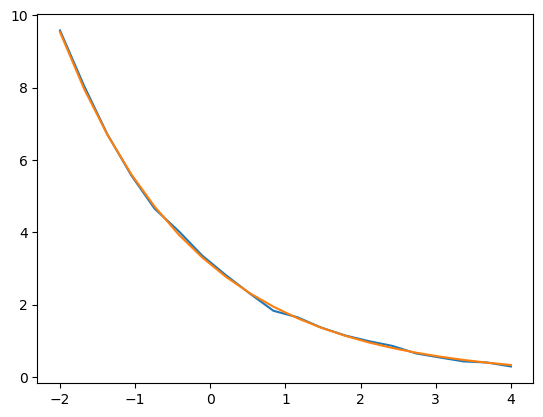

In [9]:
import matplotlib.pyplot as plt
plt.plot(x,y)
plt.plot(x, 3.11 * np.exp(-0.56*x))

In [11]:
#liniowy
from sklearn.linear_model import LinearRegression
import numpy as np

x = np.array([-2.0, -1.68, -1.37, -1.05, -0.74, -0.42, -0.11, 0.21, 0.53, 0.84, 1.16, 1.47, 1.79, 2.11, 2.42, 2.74, 3.05, 3.37, 3.68, 4.0])
y = np.array([9.58, 8.05, 6.71, 5.57, 4.65, 4.03, 3.36, 2.81, 2.3, 1.83, 1.65, 1.37, 1.15, 0.99, 0.86, 0.65, 0.54, 0.43, 0.4, 0.29])

x= x.reshape(-1, 1) #puts every value in seperate row
#LinearRegression() expects a matric of samples and features
#we reshape x so it has 20 values for one feature 

#fit the model
model = LinearRegression()
model.fit(x, np.log(y)) #model: log(y) = ax +b but we want log(y) = -bx*1 + log(a)  = -bx + log(a)

#find coefficients
b = -model.coef_[0]  # -b
a = np.exp(model.intercept_)  #  exp(a)

print(f"a = {a}, b = {b}")


a = 3.1148666954632596, b = 0.569751438837088


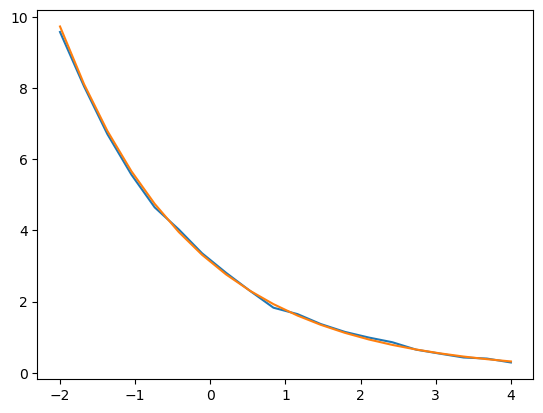

In [8]:
import matplotlib.pyplot as plt
plt.plot(x,y)
plt.plot(x, a * np.exp(-b*x))